In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Raw Data

In [18]:
food = pd.read_csv('../data/food.csv')
food_nutrient = pd.read_csv('../data/food_nutrient.csv')
nutrient = pd.read_csv('../data/nutrient.csv')
food_category = pd.read_csv('../data/food_category.csv')

print('food:          ', food.shape)
print('food_nutrient: ', food_nutrient.shape)
print('nutrient:      ', nutrient.shape)
print('food_category: ', food_category.shape)

food:           (7793, 5)
food_nutrient:  (644125, 11)
nutrient:       (474, 5)
food_category:  (28, 3)


## 2. Preview Each Table

In [19]:
food.head(3)

,fdc_id,data_type,description,food_category_id,publication_date
0,167512,sr_legacy_food,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...",18,2019-04-01
1,167513,sr_legacy_food,"Pillsbury, Cinnamon Rolls with Icing, refriger...",18,2019-04-01
2,167514,sr_legacy_food,"Kraft Foods, Shake N Bake Original Recipe, Coa...",18,2019-04-01


In [20]:
food_nutrient.head(3)

,id,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired
0,1283674,167512,1003,5.88,1,46.0,NaN,NaN,NaN,NaN,NaN
1,1283675,167512,1007,3.50,1,46.0,NaN,NaN,NaN,NaN,NaN
2,1283676,167512,1062,1286.00,0,49.0,NaN,NaN,NaN,NaN,NaN


In [21]:
nutrient.head(10)

,id,name,unit_name,nutrient_nbr,rank
0,2047,Energy (Atwater General Factors),KCAL,957.0,280.0
1,2048,Energy (Atwater Specific Factors),KCAL,958.0,290.0
2,1001,Solids,G,201.0,200.0
3,1002,Nitrogen,G,202.0,500.0
4,1003,Protein,G,203.0,600.0
5,1004,Total lipid (fat),G,204.0,800.0
6,1005,"Carbohydrate, by difference",G,205.0,1110.0
7,1006,"Fiber, crude (DO NOT USE - Archived)",G,206.0,999999.0
8,1007,Ash,G,207.0,1000.0
9,1008,Energy,KCAL,208.0,300.0


In [22]:
food_category

,id,code,description
0,1,100,Dairy and Egg Products
1,2,200,Spices and Herbs
2,3,300,Baby Foods
3,4,400,Fats and Oils
4,5,500,Poultry Products
5,6,600,"Soups, Sauces, and Gravies"
6,7,700,Sausages and Luncheon Meats
7,8,800,Breakfast Cereals
8,9,900,Fruits and Fruit Juices
9,10,1000,Pork Products


## 3. Select Key Nutrients

We focus on macronutrients and selected micronutrients that are well-represented across most food items.

In [23]:
# Nutrient IDs of interest (USDA standard IDs)
NUTRIENTS_OF_INTEREST = {
    1003: 'Protein (g)',
    1004: 'Total Fat (g)',
    1005: 'Carbohydrates (g)',
    1079: 'Fiber (g)',
    2000: 'Total Sugars (g)',
    1008: 'Energy (kcal)',
    1087: 'Calcium (mg)',
    1089: 'Iron (mg)',
    1090: 'Magnesium (mg)',
    1093: 'Sodium (mg)',
    1095: 'Zinc (mg)',
    1106: 'Vitamin A (mcg)',
    1162: 'Vitamin C (mg)',
    1165: 'Thiamin (mg)',
    1166: 'Riboflavin (mg)',
    1175: 'Vitamin B6 (mg)',
    1177: 'Folate (mcg)',
    1178: 'Vitamin B12 (mcg)',
    1114: 'Vitamin D (mcg)',
    1109: 'Vitamin E (mg)',
}

# Confirm which of these exist in the dataset
available = nutrient[nutrient['id'].isin(NUTRIENTS_OF_INTEREST)][['id', 'name', 'unit_name']]
print(f'{len(available)} of {len(NUTRIENTS_OF_INTEREST)} target nutrients found in dataset')
available

20 of 20 target nutrients found in dataset


,id,name,unit_name
4,1003,Protein,G
5,1004,Total lipid (fat),G
6,1005,"Carbohydrate, by difference",G
9,1008,Energy,KCAL
80,1079,"Fiber, total dietary",G
88,1087,"Calcium, Ca",MG
90,1089,"Iron, Fe",MG
91,1090,"Magnesium, Mg",MG
94,1093,"Sodium, Na",MG
96,1095,"Zinc, Zn",MG


## 4. Build Food × Nutrient Matrix

Pivot `food_nutrient` so each row is a food item and each column is a nutrient amount (per 100g).

In [24]:
# Filter to nutrients of interest only
fn_filtered = food_nutrient[food_nutrient['nutrient_id'].isin(NUTRIENTS_OF_INTEREST)][['fdc_id', 'nutrient_id', 'amount']]

# Pivot: rows = foods, columns = nutrients
nutrient_matrix = fn_filtered.pivot_table(index='fdc_id', columns='nutrient_id', values='amount', aggfunc='mean')
nutrient_matrix.columns = [NUTRIENTS_OF_INTEREST[col] for col in nutrient_matrix.columns]
nutrient_matrix = nutrient_matrix.reset_index()

print('Nutrient matrix shape:', nutrient_matrix.shape)
nutrient_matrix.head(3)

Nutrient matrix shape: (7793, 21)


,fdc_id,Protein (g),Total Fat (g),Carbohydrates (g),Energy (kcal),Fiber (g),Calcium (mg),Iron (mg),Magnesium (mg),Sodium (mg),...,Vitamin A (mcg),Vitamin E (mg),Vitamin D (mcg),Vitamin C (mg),Thiamin (mg),Riboflavin (mg),Vitamin B6 (mg),Folate (mcg),Vitamin B12 (mcg),Total Sugars (g)
0,167512,5.88,13.24,41.18,307.0,1.2,NaN,2.12,NaN,1059.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.88
1,167513,4.34,11.27,53.42,330.0,1.4,28.0,1.93,NaN,780.0,...,0.0,NaN,NaN,0.1,NaN,NaN,NaN,NaN,NaN,21.34
2,167514,6.10,3.70,79.80,377.0,NaN,NaN,NaN,NaN,2182.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Merge with Food and Category Info

In [25]:
# Attach food descriptions and category IDs
df = nutrient_matrix.merge(
    food[['fdc_id', 'description', 'food_category_id']],
    on='fdc_id', how='inner'
)

# Attach category names
food_category = food_category.rename(columns={'id': 'food_category_id', 'description': 'category'})
df = df.merge(food_category[['food_category_id', 'category']], on='food_category_id', how='left')

print('Final dataframe shape:', df.shape)
df.head(3)

Final dataframe shape: (7793, 24)


,fdc_id,Protein (g),Total Fat (g),Carbohydrates (g),Energy (kcal),Fiber (g),Calcium (mg),Iron (mg),Magnesium (mg),Sodium (mg),...,Vitamin C (mg),Thiamin (mg),Riboflavin (mg),Vitamin B6 (mg),Folate (mcg),Vitamin B12 (mcg),Total Sugars (g),description,food_category_id,category
0,167512,5.88,13.24,41.18,307.0,1.2,NaN,2.12,NaN,1059.0,...,NaN,NaN,NaN,NaN,NaN,NaN,5.88,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...",18,Baked Products
1,167513,4.34,11.27,53.42,330.0,1.4,28.0,1.93,NaN,780.0,...,0.1,NaN,NaN,NaN,NaN,NaN,21.34,"Pillsbury, Cinnamon Rolls with Icing, refriger...",18,Baked Products
2,167514,6.10,3.70,79.80,377.0,NaN,NaN,NaN,NaN,2182.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Kraft Foods, Shake N Bake Original Recipe, Coa...",18,Baked Products


## 6. Missing Value Analysis & Principled Imputation

Missing nutrient data in the USDA SR Legacy dataset is not random (not MCAR). We distinguish two mechanisms:

- **MNAR (Missing Not At Random):** A nutrient is not reported *because its value is known to be negligible* for that food type — e.g., Vitamin C in meats, Vitamin B12 in plant foods, Vitamin D in most foods. The missing value itself drives the absence. → **Impute with 0.**
- **MAR (Missing At Random):** A nutrient is missing because that food category was not systematically tested for it, but the value is not predictably zero. → **Impute with within-category median** (conditions on the observed food category).
- **Too sparse to impute (>50% missing, MAR):** For MAR nutrients where over half the data is missing, within-category medians would be estimated from very few observations and could introduce more noise than signal. → **Exclude from analysis.**

Simple row-dropping would create selection bias toward commercially processed foods that carry full nutritional labels, distorting clustering results.

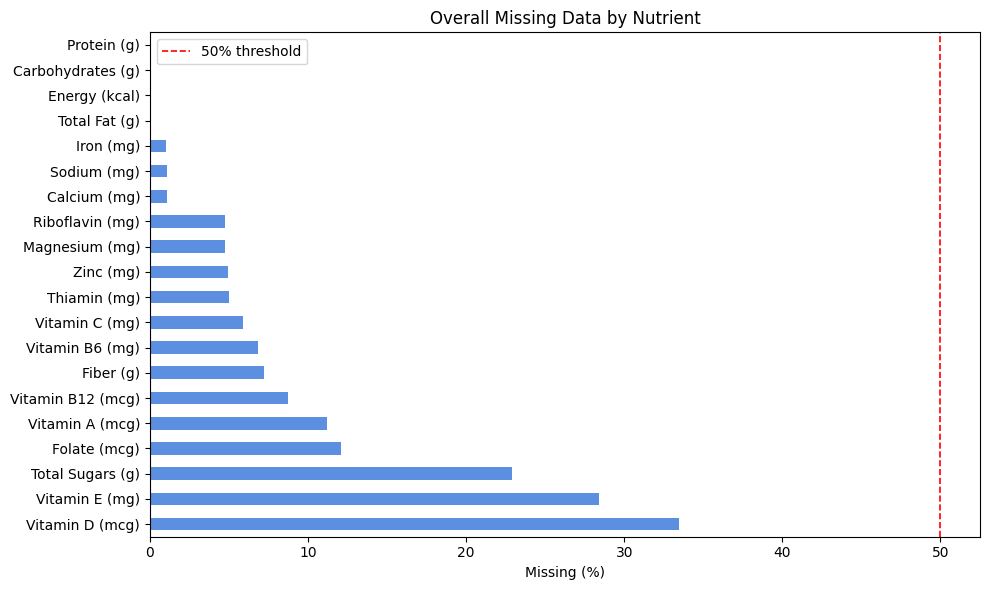

,Nutrient,Missing (%)
0,Vitamin D (mcg),33.5
1,Vitamin E (mg),28.4
2,Total Sugars (g),22.9
3,Folate (mcg),12.1
4,Vitamin A (mcg),11.2
5,Vitamin B12 (mcg),8.7
6,Fiber (g),7.2
7,Vitamin B6 (mg),6.8
8,Vitamin C (mg),5.9
9,Thiamin (mg),5.0


In [26]:
nutrient_cols = list(NUTRIENTS_OF_INTEREST.values())

# Overall missingness per nutrient
missing_pct = df[nutrient_cols].isnull().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e05c5c' if p > 50 else '#5c8fe0' for p in missing_pct]
missing_pct.plot(kind='barh', ax=ax, color=colors[::-1])
ax.axvline(50, color='red', linestyle='--', linewidth=1.2, label='50% threshold')
ax.set_title('Overall Missing Data by Nutrient')
ax.set_xlabel('Missing (%)')
ax.legend()
plt.tight_layout()
plt.show()

missing_pct.reset_index().rename(columns={'index': 'Nutrient', 0: 'Missing (%)'}).round(1)

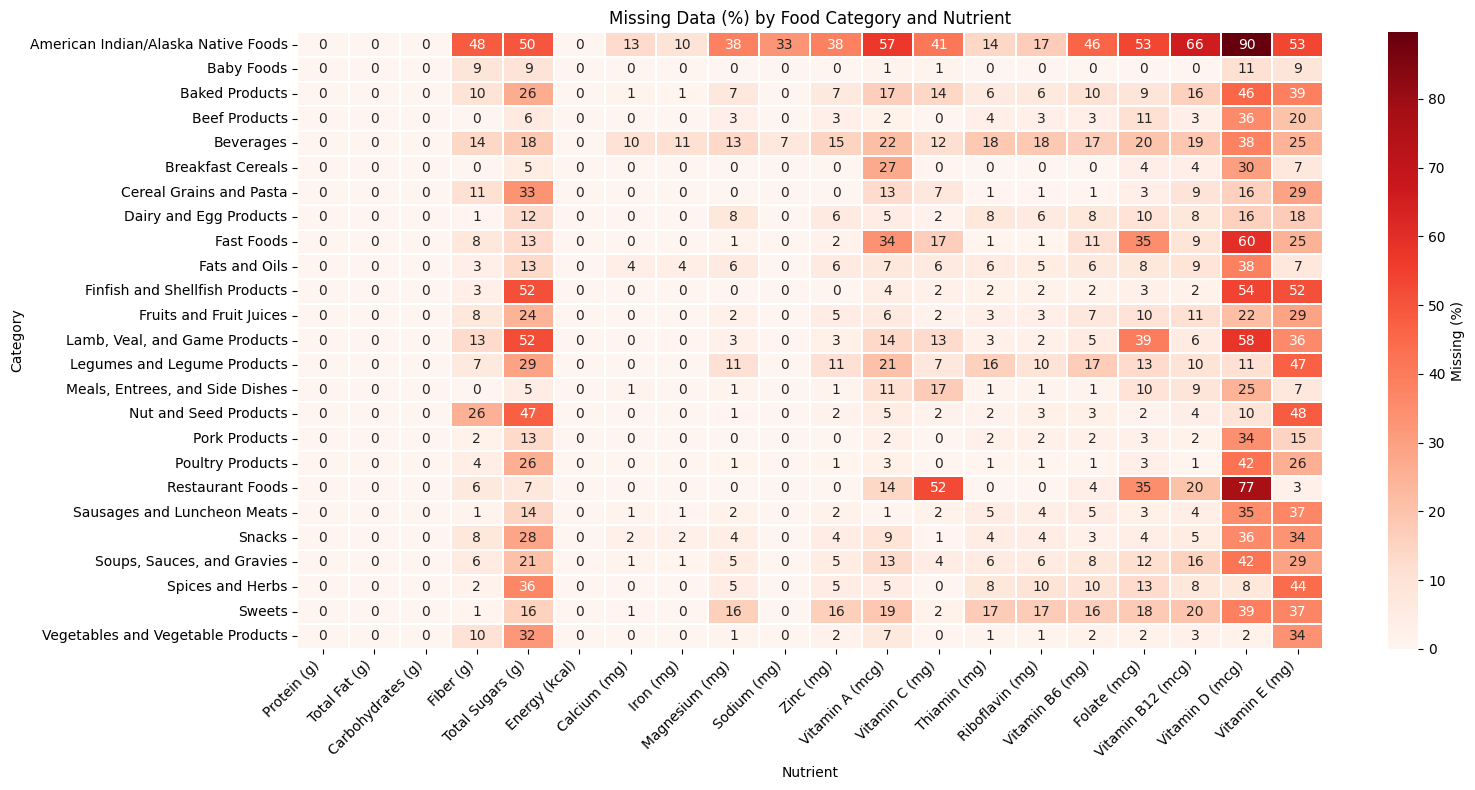

In [27]:
# Missingness by food category — reveals MAR vs MNAR patterns
miss_by_cat = (
    df.groupby('category')[nutrient_cols]
    .apply(lambda g: g.isnull().mean() * 100)
    .round(1)
)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(miss_by_cat, cmap='Reds', annot=True, fmt='.0f',
            linewidths=0.3, ax=ax, cbar_kws={'label': 'Missing (%)'})
ax.set_title('Missing Data (%) by Food Category and Nutrient')
ax.set_xlabel('Nutrient')
ax.set_ylabel('Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [28]:
# Classify each nutrient by missing data mechanism

# MNAR: biologically near-zero for many food categories — absence signals true zero
MNAR_NUTRIENTS = [
    'Vitamin C (mg)',    # essentially 0 in meats, fats, oils
    'Vitamin D (mcg)',   # essentially 0 in most plant and many animal foods
    'Vitamin B12 (mcg)', # essentially 0 in plant-based foods
    'Vitamin A (mcg)',   # essentially 0 in refined/processed foods and many grains
]
MNAR_NUTRIENTS = [n for n in MNAR_NUTRIENTS if n in nutrient_cols]

# MAR: missingness driven by whether the food was tested, not by the nutrient value
# Split into well-covered (<=50% missing) and too sparse (>50% missing)
MAR_ALL = [n for n in nutrient_cols if n not in MNAR_NUTRIENTS]
MAR_KEEP  = [n for n in MAR_ALL if missing_pct[n] <= 50]
MAR_DROP  = [n for n in MAR_ALL if missing_pct[n] >  50]

print('MNAR  → impute with 0:                   ', MNAR_NUTRIENTS)
print('MAR   → impute with within-category median:', MAR_KEEP)
print('MAR   → too sparse, exclude:              ', MAR_DROP)

MNAR  → impute with 0:                    ['Vitamin C (mg)', 'Vitamin D (mcg)', 'Vitamin B12 (mcg)', 'Vitamin A (mcg)']
MAR   → impute with within-category median: ['Protein (g)', 'Total Fat (g)', 'Carbohydrates (g)', 'Fiber (g)', 'Total Sugars (g)', 'Energy (kcal)', 'Calcium (mg)', 'Iron (mg)', 'Magnesium (mg)', 'Sodium (mg)', 'Zinc (mg)', 'Thiamin (mg)', 'Riboflavin (mg)', 'Vitamin B6 (mg)', 'Folate (mcg)', 'Vitamin E (mg)']
MAR   → too sparse, exclude:               []


In [29]:
# Step 1: MNAR — impute with 0
df_imputed = df.copy()
df_imputed[MNAR_NUTRIENTS] = df_imputed[MNAR_NUTRIENTS].fillna(0)

# Step 2: MAR (well-covered) — impute with within-category median
df_imputed[MAR_KEEP] = df_imputed.groupby('category')[MAR_KEEP].transform(
    lambda col: col.fillna(col.median())
)

# Step 3: Drop the too-sparse MAR nutrients entirely
analysis_nutrients = MNAR_NUTRIENTS + MAR_KEEP
df_imputed = df_imputed[['fdc_id', 'description', 'category'] + analysis_nutrients]

# Step 4: Drop any remaining NaN rows
#   These are edge cases: foods with no category whose MAR imputation produced no median
before = len(df_imputed)
df_clean = df_imputed.dropna()
after = len(df_clean)
print(f'Rows dropped as uncategorised edge cases: {before - after}')
print(f'Clean dataset: {df_clean.shape[0]} foods × {len(analysis_nutrients)} nutrients')

Rows dropped as uncategorised edge cases: 0
Clean dataset: 7793 foods × 20 nutrients


In [30]:
# Confirm no remaining missing values
remaining = df_clean[analysis_nutrients].isnull().sum().sum()
print(f'Remaining missing values: {remaining}')   # should be 0

Remaining missing values: 0


## 7. Exploratory Data Analysis

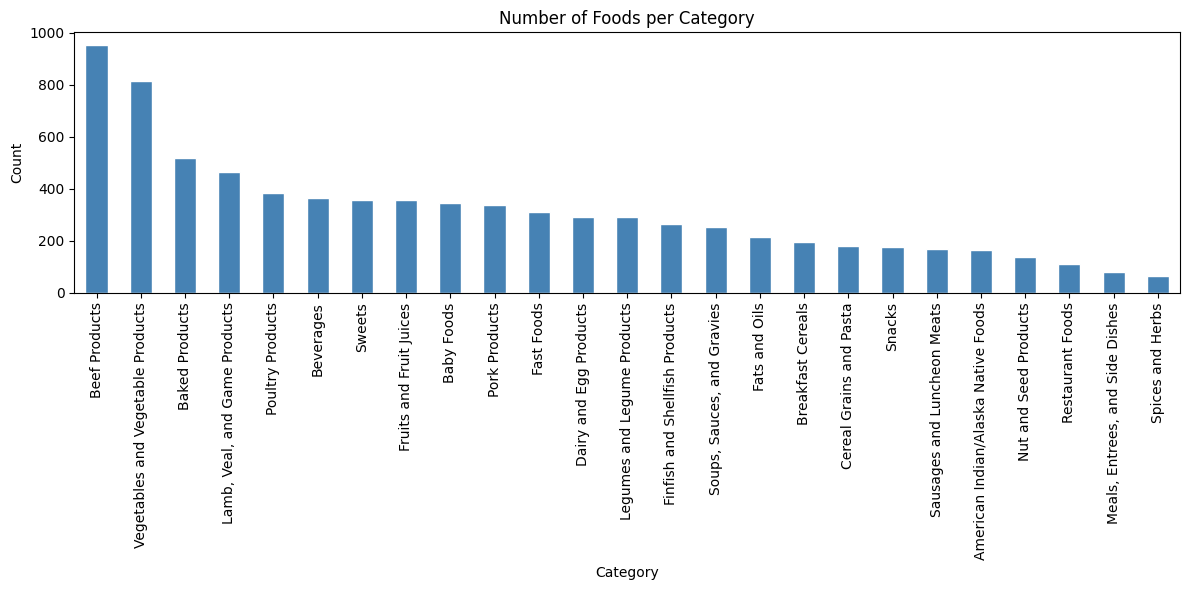

In [39]:
# Foods per category
cat_counts = df_clean['category'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
cat_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Number of Foods per Category')
ax.set_xlabel('Category')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

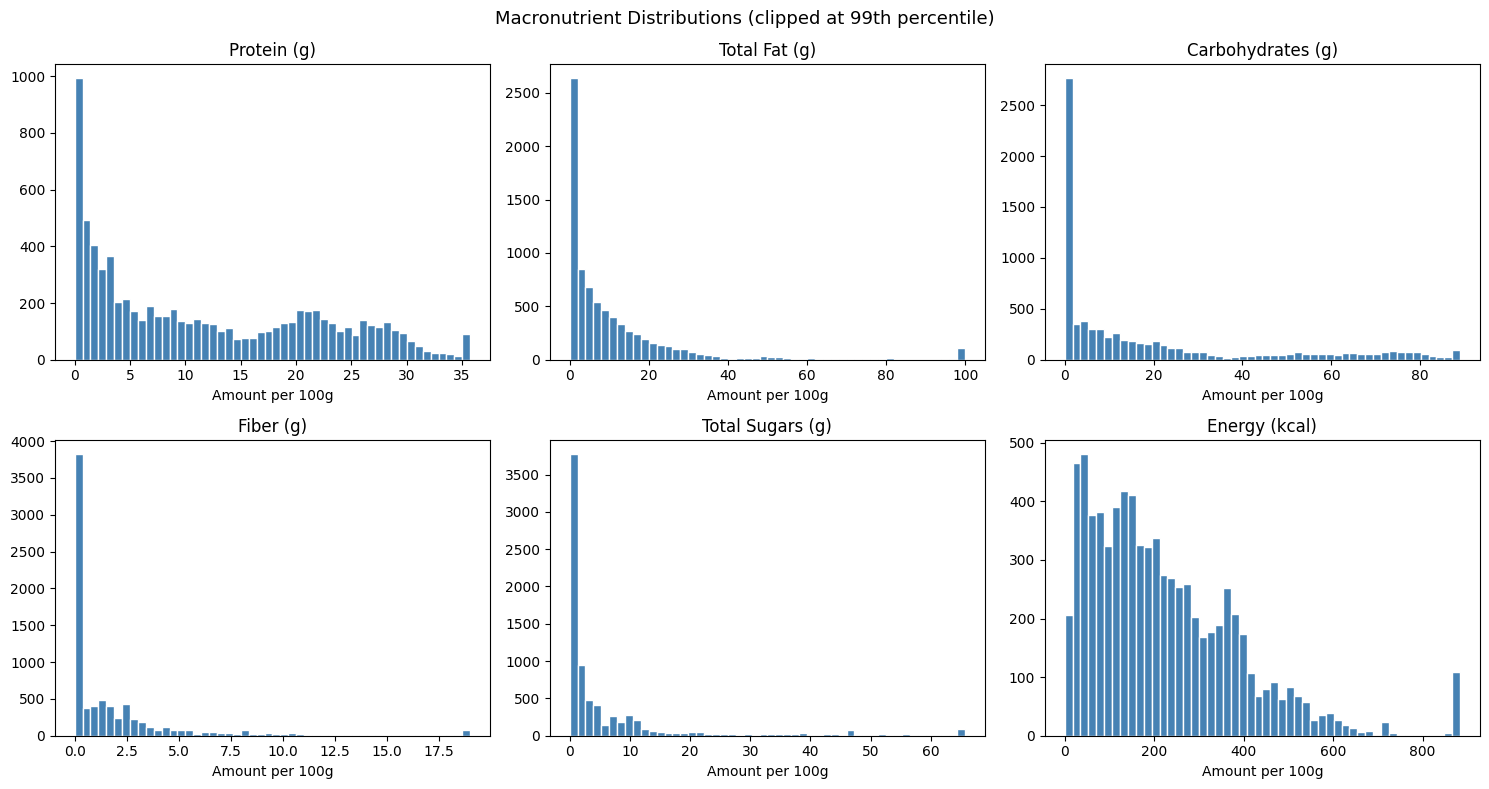

In [32]:
# Distribution of macronutrients
macros = [c for c in analysis_nutrients if c in [
    'Protein (g)', 'Total Fat (g)', 'Carbohydrates (g)',
    'Fiber (g)', 'Total Sugars (g)', 'Energy (kcal)'
]]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(macros):
    axes[i].hist(df_clean[col].clip(upper=df_clean[col].quantile(0.99)), bins=50,
                 color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Amount per 100g')

for j in range(len(macros), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Macronutrient Distributions (clipped at 99th percentile)', fontsize=13)
plt.tight_layout()
plt.show()

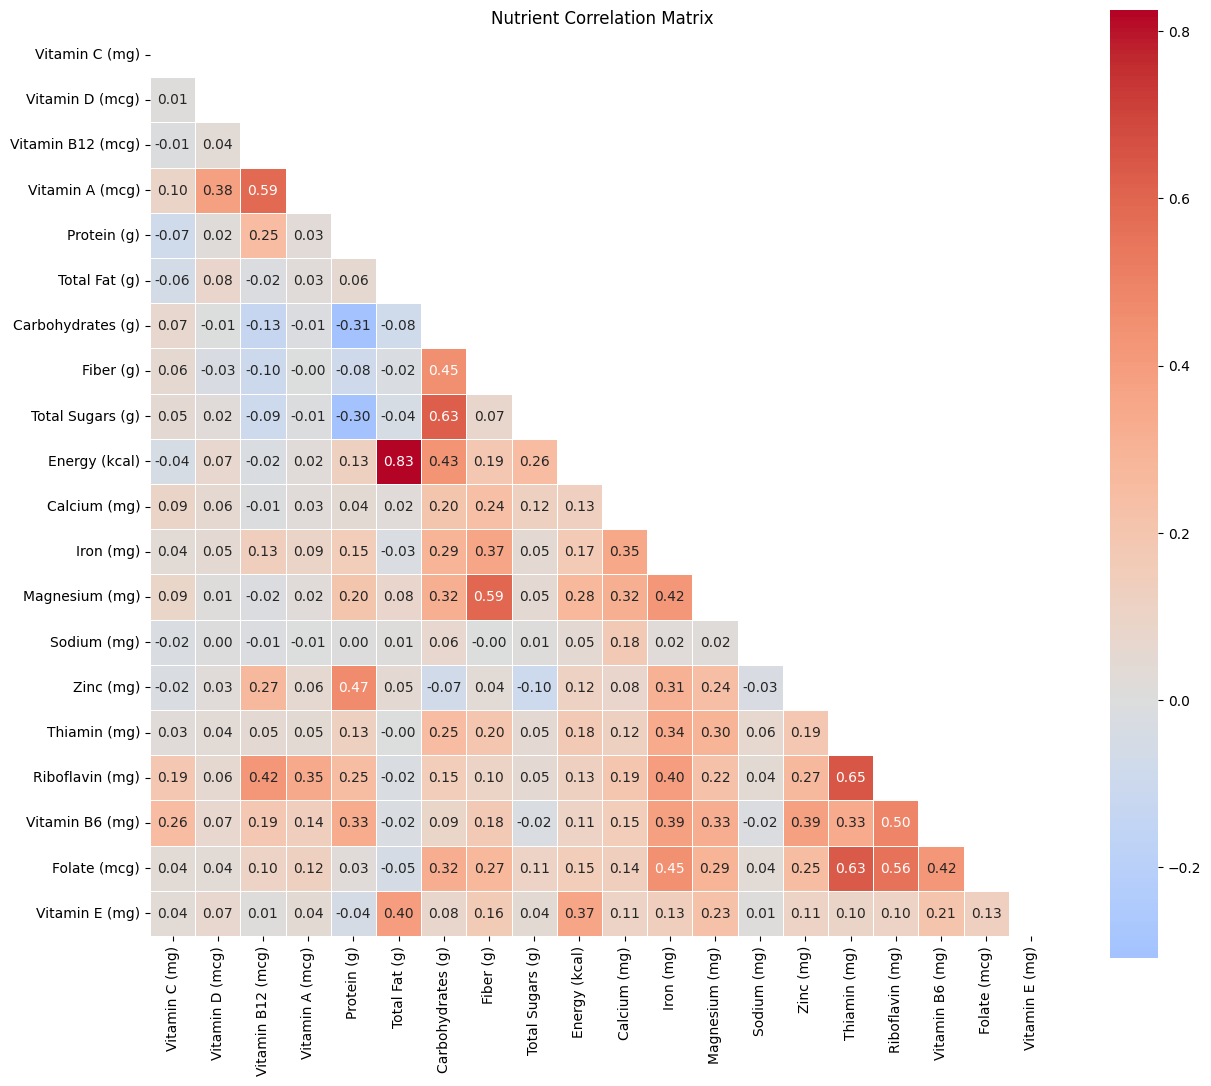

In [33]:
# Correlation heatmap of nutrients
fig, ax = plt.subplots(figsize=(13, 11))
corr = df_clean[analysis_nutrients].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Nutrient Correlation Matrix')
plt.tight_layout()
plt.show()

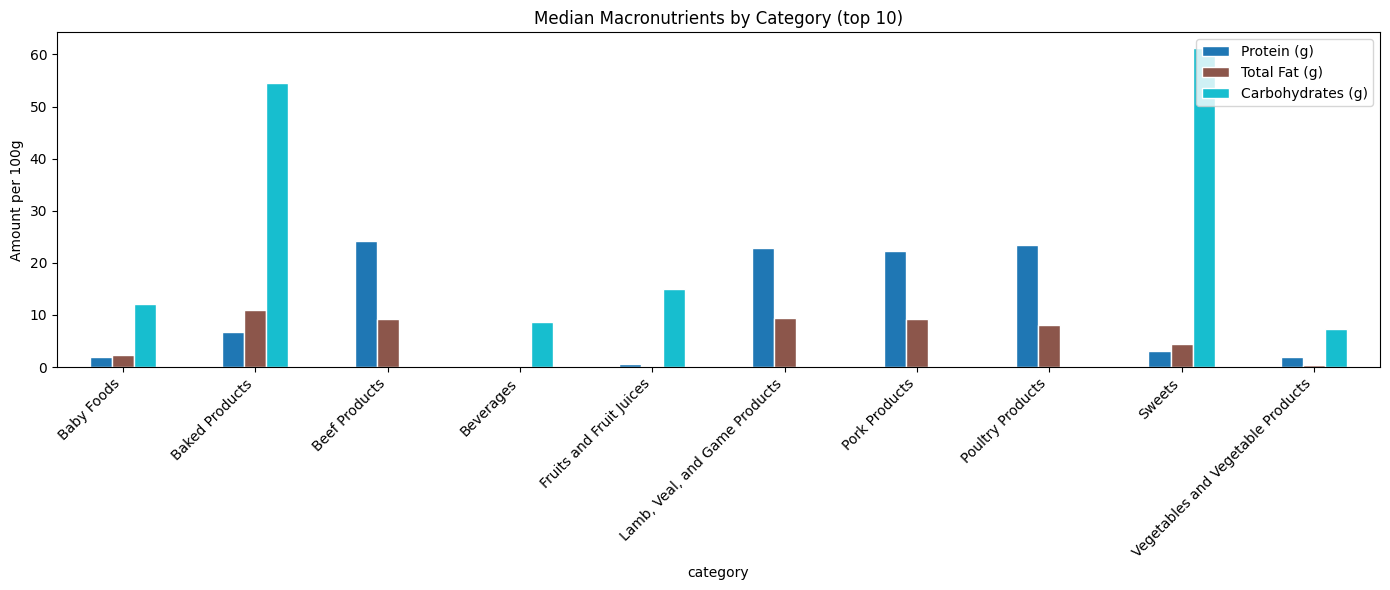

In [34]:
# Median macronutrients by category (top 10 categories by food count)
top_cats = cat_counts.head(10).index.tolist()
plot_macros = [c for c in ['Protein (g)', 'Total Fat (g)', 'Carbohydrates (g)'] if c in analysis_nutrients]

cat_median = df_clean[df_clean['category'].isin(top_cats)].groupby('category')[plot_macros].median()

cat_median.plot(kind='bar', figsize=(14, 6), colormap='tab10', edgecolor='white')
plt.title('Median Macronutrients by Category (top 10)')
plt.ylabel('Amount per 100g')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [35]:
# Save clean dataset for use in subsequent notebooks
df_clean.to_csv('../data/food_nutrients_clean.csv', index=False)
print('Saved clean dataset to data/food_nutrients_clean.csv')
print(f'Columns: {df_clean.columns.tolist()}')

Saved clean dataset to data/food_nutrients_clean.csv
Columns: ['fdc_id', 'description', 'category', 'Vitamin C (mg)', 'Vitamin D (mcg)', 'Vitamin B12 (mcg)', 'Vitamin A (mcg)', 'Protein (g)', 'Total Fat (g)', 'Carbohydrates (g)', 'Fiber (g)', 'Total Sugars (g)', 'Energy (kcal)', 'Calcium (mg)', 'Iron (mg)', 'Magnesium (mg)', 'Sodium (mg)', 'Zinc (mg)', 'Thiamin (mg)', 'Riboflavin (mg)', 'Vitamin B6 (mg)', 'Folate (mcg)', 'Vitamin E (mg)']
